# MWE 10 - Lattice-based vug sensitivity with multi-realization baselines

This notebook implements the **lattice-based** vug sensitivity idea discussed for the issue:

- Start from a synthetic Cartesian pore-throat lattice (matrix proxy).
- Build multiple stochastic baseline realizations by perturbing pore/throat sizes.
- Insert one large vug as a super-pore by replacing an ellipsoidal pore subset.
- Compare porosity and absolute permeability (`Kabs`) against each realization baseline.

Included vug families:

- spherical vugs
- ellipsoids stretched in the flow direction
- ellipsoids stretched orthogonal to flow

Scientific caveats (important):

- This is a **network-level synthetic model**, not a direct image-based extraction.
- The vug insertion rule (subset replacement + reconnection) is one mechanistic assumption,
  not a unique physical truth.
- Conductance uses `generic_poiseuille`; conclusions can shift with constitutive choices.
- Geometry perturbations are synthetic and may not represent real rock statistics.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover - optional notebook dependency
    _tqdm = None

from voids.core.network import Network
from voids.examples import make_cartesian_mesh_network
from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly
from voids.generators import (
    build_lattice_vug_templates_3d,
    insert_vug_superpore,
    update_network_geometry_from_radii,
)

/Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def iter_progress(
    iterable,
    *,
    desc: str | None = None,
    total: int | None = None,
    enabled: bool = True,
    leave: bool = False,
):
    """Wrap iterable with tqdm when available."""

    if not enabled or _tqdm is None:
        return iterable
    return _tqdm(
        iterable,
        desc=desc,
        total=total,
        dynamic_ncols=True,
        leave=leave,
    )

In [3]:
# Study controls
FLOW_AXIS = "x"
MESH_SHAPE = (16, 16, 16)
SPACING_M = 40.0e-6

BASE_PORE_RADIUS_M = 0.24 * SPACING_M
BASE_THROAT_RADIUS_M = 0.12 * SPACING_M

# Stochastic baseline controls
N_BASELINES = 15
BASE_SEED = 20260305
PORE_RADIUS_REL_STD = 0.10
THROAT_RADIUS_REL_STD = 0.12

# Equivalent-vug-radius grid (in lattice-spacing units)
EQUIV_RADII_SPACING = [1.4, 1.7, 2.0, 2.3, 2.6]
ELLIPSOID_ASPECT = 1.8  # major/minor axis ratio for ellipsoids
VUG_VOLUME_MATCH_RTOL = 1.0e-12

# Numerics and plotting
PLOTLY_MAX_THROATS_BASELINE = 2500
PLOTLY_MAX_THROATS_VUG: int | None = None  # keep all vug connections visible
PLOTLY_LAYOUT = {"width": 900, "height": 650}
PLOTLY_SIZE_LIMITS = (None, None)  # preserve full relative size range

USE_TQDM = os.environ.get("VOIDS_DISABLE_TQDM", "0") != "1"
SMOKE_MODE = os.environ.get("VOIDS_VUG_SMOKE", "0") == "1"
if SMOKE_MODE:
    N_BASELINES = 2
    EQUIV_RADII_SPACING = EQUIV_RADII_SPACING[:2]

print("mesh shape:", MESH_SHAPE)
print("spacing [m]:", SPACING_M)
print("flow axis:", FLOW_AXIS)
print("baseline realizations:", N_BASELINES)
print("equivalent radius levels:", EQUIV_RADII_SPACING)


def generate_baseline_network(*, baseline_id: int, seed: int) -> Network:
    """Create one stochastic lattice baseline realization."""

    net = make_cartesian_mesh_network(
        MESH_SHAPE,
        spacing=SPACING_M,
        pore_radius=BASE_PORE_RADIUS_M,
        throat_radius=BASE_THROAT_RADIUS_M,
        units={"length": "m", "pressure": "Pa"},
    )

    rng = np.random.default_rng(seed)
    pore_factor = np.clip(
        rng.normal(loc=1.0, scale=PORE_RADIUS_REL_STD, size=net.Np),
        0.60,
        1.45,
    )
    throat_factor = np.clip(
        rng.normal(loc=1.0, scale=THROAT_RADIUS_REL_STD, size=net.Nt),
        0.55,
        1.50,
    )

    update_network_geometry_from_radii(
        net,
        pore_radius=BASE_PORE_RADIUS_M * pore_factor,
        throat_radius=BASE_THROAT_RADIUS_M * throat_factor,
    )

    net.extra["baseline_id"] = int(baseline_id)
    net.extra["baseline_seed"] = int(seed)
    return net


def save_network_png_matplotlib(
    *,
    net: Network,
    pore_pressure: np.ndarray,
    png_path: Path,
    title: str,
    max_throats: int | None = 2500,
) -> None:
    """Save a static 3D network PNG via Matplotlib fallback exporter."""

    coords = np.asarray(net.pore_coords, dtype=float)
    conns = np.asarray(net.throat_conns, dtype=int)
    if max_throats is not None and conns.shape[0] > max_throats:
        idx = np.linspace(0, conns.shape[0] - 1, max_throats, dtype=int)
        conns = conns[idx]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)

    for i, j in conns:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            [coords[i, 2], coords[j, 2]],
            color="0.45",
            alpha=0.20,
            linewidth=0.4,
        )

    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        c=np.asarray(pore_pressure, dtype=float),
        s=10,
        cmap="viridis",
        alpha=0.9,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.08, label="Pressure [Pa]")
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)

mesh shape: (16, 16, 16)
spacing [m]: 4e-05
flow axis: x
baseline realizations: 15
equivalent radius levels: [1.4, 1.7, 2.0, 2.3, 2.6]


## Build vug template families

To enable fair comparison across shapes, each configuration index shares
approximately the same equivalent radius across families.


In [5]:
vug_templates, volume_match_report = build_lattice_vug_templates_3d(
    equiv_radii_spacing=EQUIV_RADII_SPACING,
    spacing_m=SPACING_M,
    aspect=ELLIPSOID_ASPECT,
)

print("Total vug templates:", len(vug_templates))
print("Per family configs:", len(EQUIV_RADII_SPACING))
print("Volume-match diagnostics (relative error vs target r_eq^3):")
for cfg_idx, err_s, err_f, err_o in volume_match_report:
    print(f"  cfg{cfg_idx}: sphere={err_s:.3e}, flow={err_f:.3e}, orth={err_o:.3e}")
    if max(err_s, err_f, err_o) > VUG_VOLUME_MATCH_RTOL:
        raise RuntimeError(
            f"Volume-matching tolerance exceeded at cfg{cfg_idx}: "
            f"{max(err_s, err_f, err_o):.3e} > {VUG_VOLUME_MATCH_RTOL:.3e}"
        )

Total vug templates: 15
Per family configs: 5
Volume-match diagnostics (relative error vs target r_eq^3):
  cfg1: sphere=0.000e+00, flow=0.000e+00, orth=0.000e+00
  cfg2: sphere=0.000e+00, flow=3.211e-16, orth=3.211e-16
  cfg3: sphere=0.000e+00, flow=1.972e-16, orth=1.972e-16
  cfg4: sphere=0.000e+00, flow=0.000e+00, orth=0.000e+00
  cfg5: sphere=0.000e+00, flow=1.795e-16, orth=1.795e-16


## Generate baseline realizations

Each baseline is a stochastically perturbed lattice with the same topology and
boundary labels but different geometric radii fields.


In [6]:
baseline_networks: dict[int, Network] = {}
for baseline_id in iter_progress(
    range(1, N_BASELINES + 1),
    desc="Generating lattice baselines",
    total=N_BASELINES,
    enabled=USE_TQDM,
    leave=True,
):
    seed = BASE_SEED + 1000 * baseline_id
    baseline_networks[baseline_id] = generate_baseline_network(
        baseline_id=baseline_id,
        seed=seed,
    )

for baseline_id in sorted(baseline_networks):
    net = baseline_networks[baseline_id]
    print(
        f"B{baseline_id:02d}: seed={net.extra['baseline_seed']} | "
        f"Np={net.Np:4d} Nt={net.Nt:5d} | phi_abs={absolute_porosity(net):.4f}"
    )

Generating lattice baselines: 100%|██████████| 15/15 [00:00<00:00, 1373.26it/s]

B01: seed=20261305 | Np=4096 Nt=11520 | phi_abs=0.1269
B02: seed=20262305 | Np=4096 Nt=11520 | phi_abs=0.1266
B03: seed=20263305 | Np=4096 Nt=11520 | phi_abs=0.1267
B04: seed=20264305 | Np=4096 Nt=11520 | phi_abs=0.1268
B05: seed=20265305 | Np=4096 Nt=11520 | phi_abs=0.1266
B06: seed=20266305 | Np=4096 Nt=11520 | phi_abs=0.1269
B07: seed=20267305 | Np=4096 Nt=11520 | phi_abs=0.1267
B08: seed=20268305 | Np=4096 Nt=11520 | phi_abs=0.1263
B09: seed=20269305 | Np=4096 Nt=11520 | phi_abs=0.1274
B10: seed=20270305 | Np=4096 Nt=11520 | phi_abs=0.1270
B11: seed=20271305 | Np=4096 Nt=11520 | phi_abs=0.1270
B12: seed=20272305 | Np=4096 Nt=11520 | phi_abs=0.1267
B13: seed=20273305 | Np=4096 Nt=11520 | phi_abs=0.1269
B14: seed=20274305 | Np=4096 Nt=11520 | phi_abs=0.1267
B15: seed=20275305 | Np=4096 Nt=11520 | phi_abs=0.1269


## Solve all baseline + vug cases

For each baseline realization:

1. solve baseline to obtain `K0`
2. insert each vug template and solve
3. store porosity, `K`, `K/K0`, and graph diagnostics


In [7]:
notebooks_env = os.environ.get("VOIDS_NOTEBOOKS_PATH")
if notebooks_env:
    notebooks_base = Path(notebooks_env).expanduser()
else:
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in (cwd, *cwd.parents):
        if (candidate / "pixi.toml").exists() and (
            candidate / "src" / "voids"
        ).exists():
            repo_root = candidate
            break
    notebooks_base = (repo_root / "notebooks") if repo_root is not None else cwd

plotly_export_root = notebooks_base / "outputs/10_mwe_lattice_based_vug_sensitivity"
plotly_html_dir = plotly_export_root / "plotly_html"
plotly_png_dir = plotly_export_root / "plotly_png"
plotly_html_dir.mkdir(parents=True, exist_ok=True)
plotly_png_dir.mkdir(parents=True, exist_ok=True)

print("Plotly HTML output:", plotly_html_dir)
print("PNG output:", plotly_png_dir)

all_results: list[dict[str, float | int | str]] = []
baseline_K: dict[int, float] = {}

# keep a small subset of insertion masks for visual QC (baseline 1 only)
mask_preview: dict[str, np.ndarray] = {}

png_export_summary = {"plotly_kaleido": 0, "matplotlib_fallback": 0, "failed": 0}
plotly_failures: list[str] = []

baseline_iter = iter_progress(
    sorted(baseline_networks.keys()),
    desc="Running lattice studies",
    total=len(baseline_networks),
    enabled=USE_TQDM,
    leave=True,
)
for baseline_id in baseline_iter:
    net_baseline = baseline_networks[baseline_id]

    # Solve baseline first
    bc = PressureBC(
        f"inlet_{FLOW_AXIS}min", f"outlet_{FLOW_AXIS}max", pin=2.0e5, pout=1.0e5
    )
    baseline_res = solve(
        net_baseline,
        fluid=FluidSinglePhase(viscosity=1.0e-3),
        bc=bc,
        axis=FLOW_AXIS,
        options=SinglePhaseOptions(
            conductance_model="generic_poiseuille", solver="direct"
        ),
    )
    k0 = float(baseline_res.permeability[FLOW_AXIS])
    baseline_K[baseline_id] = k0

    coord_baseline = coordination_numbers(net_baseline)
    base_case = f"B{baseline_id}_baseline"
    all_results.append(
        {
            "baseline_id": baseline_id,
            "case": base_case,
            "family": "baseline",
            "orientation": "none",
            "config_index": 0,
            "rx_spacing": 0.0,
            "ry_spacing": 0.0,
            "rz_spacing": 0.0,
            "equivalent_radius_spacing": 0.0,
            "removed_pores": 0,
            "boundary_neighbors": 0,
            "phi_abs": float(absolute_porosity(net_baseline)),
            f"phi_eff_{FLOW_AXIS}": float(
                effective_porosity(net_baseline, axis=FLOW_AXIS)
            ),
            "K_axis_m2": k0,
            "K_ratio_to_baseline": 1.0,
            "Q_m3_s": float(baseline_res.total_flow_rate),
            "mass_balance_error": float(baseline_res.mass_balance_error),
            "Np": int(net_baseline.Np),
            "Nt": int(net_baseline.Nt),
            "mean_coordination": float(coord_baseline.mean()),
        }
    )

    # Baseline plot export
    try:
        fig = plot_network_plotly(
            net_baseline,
            point_scalars=baseline_res.pore_pressure,
            max_throats=PLOTLY_MAX_THROATS_BASELINE,
            point_size_limits=PLOTLY_SIZE_LIMITS,
            throat_size_limits=PLOTLY_SIZE_LIMITS,
            title=f"B{baseline_id} baseline | K{FLOW_AXIS}={k0:.3e} m2",
            layout_kwargs=PLOTLY_LAYOUT,
        )
        html_path = plotly_html_dir / f"{base_case}.html"
        png_path = plotly_png_dir / f"{base_case}.png"
        fig.write_html(html_path, include_plotlyjs="cdn")
        try:
            fig.write_image(png_path, format="png", scale=2)
            png_export_summary["plotly_kaleido"] += 1
        except Exception:
            save_network_png_matplotlib(
                net=net_baseline,
                pore_pressure=np.asarray(baseline_res.pore_pressure, dtype=float),
                png_path=png_path,
                title=f"{base_case} pressure field",
                max_throats=PLOTLY_MAX_THROATS_BASELINE,
            )
            png_export_summary["matplotlib_fallback"] += 1
    except Exception as exc:
        plotly_failures.append(f"{base_case}: {exc}")
        png_export_summary["failed"] += 1

    # Vug cases for this baseline
    template_iter = iter_progress(
        list(enumerate(vug_templates, start=1)),
        desc=f"B{baseline_id}: vug configs",
        total=len(vug_templates),
        enabled=USE_TQDM,
        leave=False,
    )
    for j, tpl in template_iter:
        case_name = f"B{baseline_id}_{tpl['case']}"
        radii_xyz_m = tuple(float(v) for v in tuple(tpl["radii_xyz_m"]))

        net_vug, vug_meta = insert_vug_superpore(
            net_baseline,
            radii_xyz=radii_xyz_m,
        )
        if baseline_id == 1:
            mask_preview[case_name] = np.asarray(
                vug_meta["inside_mask_original"], dtype=bool
            )

        res = solve(
            net_vug,
            fluid=FluidSinglePhase(viscosity=1.0e-3),
            bc=bc,
            axis=FLOW_AXIS,
            options=SinglePhaseOptions(
                conductance_model="generic_poiseuille", solver="direct"
            ),
        )

        kval = float(res.permeability[FLOW_AXIS])
        coord = coordination_numbers(net_vug)
        row = {
            "baseline_id": baseline_id,
            "case": case_name,
            "family": str(tpl["family"]),
            "orientation": str(tpl["orientation"]),
            "config_index": int(tpl["config_index"]),
            "rx_spacing": float(radii_xyz_m[0] / SPACING_M),
            "ry_spacing": float(radii_xyz_m[1] / SPACING_M),
            "rz_spacing": float(radii_xyz_m[2] / SPACING_M),
            "equivalent_radius_spacing": float(
                vug_meta["equivalent_radius_m"] / SPACING_M
            ),
            "removed_pores": int(vug_meta["removed_pores"]),
            "boundary_neighbors": int(vug_meta["boundary_neighbors"]),
            "phi_abs": float(absolute_porosity(net_vug)),
            f"phi_eff_{FLOW_AXIS}": float(effective_porosity(net_vug, axis=FLOW_AXIS)),
            "K_axis_m2": kval,
            "K_ratio_to_baseline": float(kval / k0),
            "Q_m3_s": float(res.total_flow_rate),
            "mass_balance_error": float(res.mass_balance_error),
            "Np": int(net_vug.Np),
            "Nt": int(net_vug.Nt),
            "mean_coordination": float(coord.mean()),
        }
        all_results.append(row)

        # Save Plotly render for every solved case
        try:
            fig = plot_network_plotly(
                net_vug,
                point_scalars=res.pore_pressure,
                max_throats=PLOTLY_MAX_THROATS_VUG,
                point_size_limits=PLOTLY_SIZE_LIMITS,
                throat_size_limits=PLOTLY_SIZE_LIMITS,
                title=(
                    f"B{baseline_id} | {tpl['case']} | "
                    f"K{FLOW_AXIS}={kval:.3e} m2 | K/K0={kval / k0:.3f}"
                ),
                layout_kwargs=PLOTLY_LAYOUT,
            )
            html_path = plotly_html_dir / f"{case_name}.html"
            png_path = plotly_png_dir / f"{case_name}.png"
            fig.write_html(html_path, include_plotlyjs="cdn")
            try:
                fig.write_image(png_path, format="png", scale=2)
                png_export_summary["plotly_kaleido"] += 1
            except Exception:
                save_network_png_matplotlib(
                    net=net_vug,
                    pore_pressure=np.asarray(res.pore_pressure, dtype=float),
                    png_path=png_path,
                    title=case_name,
                    max_throats=PLOTLY_MAX_THROATS_VUG,
                )
                png_export_summary["matplotlib_fallback"] += 1
        except Exception as exc:
            plotly_failures.append(f"{case_name}: {exc}")
            png_export_summary["failed"] += 1

print("Total solved cases:", len(all_results))
print("PNG export summary:", png_export_summary)
if plotly_failures:
    print("Plotly export failures (first 5):")
    for msg in plotly_failures[:5]:
        print(" -", msg)

Plotly HTML output: /Users/dtvolpatto/Work/voids/notebooks/outputs/10_mwe_lattice_based_vug_sensitivity/plotly_html
PNG output: /Users/dtvolpatto/Work/voids/notebooks/outputs/10_mwe_lattice_based_vug_sensitivity/plotly_png


Running lattice studies: 100%|██████████| 15/15 [39:08<00:00, 156.59s/it]

Total solved cases: 240
PNG export summary: {'plotly_kaleido': 0, 'matplotlib_fallback': 240, 'failed': 0}


In [8]:
header = (
    f"{'case':<44} {'family':<11} {'orientation':<20} {'cfg':>3} "
    f"{'r_eq/s':>7} {'phi_abs[%]':>10} {'K[m2]':>11} {'K/K0':>7} {'Np':>5} {'Nt':>6}"
)
print(header)
print("-" * len(header))
for row in all_results:
    print(
        f"{str(row['case']):<44} {str(row['family']):<11} {str(row['orientation']):<20} "
        f"{int(row['config_index']):>3d} {float(row['equivalent_radius_spacing']):>7.2f} "
        f"{100.0 * float(row['phi_abs']):>10.3f} {float(row['K_axis_m2']):>11.3e} "
        f"{float(row['K_ratio_to_baseline']):>7.3f} {int(row['Np']):>5d} {int(row['Nt']):>6d}"
    )

case                                         family      orientation          cfg  r_eq/s phi_abs[%]       K[m2]    K/K0    Np     Nt
-------------------------------------------------------------------------------------------------------------------------------------
B1_baseline                                  baseline    none                   0    0.00     12.691   1.408e-13   1.000  4096  11520
B1_sphere_cfg1_req1p40                       spherical   isotropic              1    1.40     13.011   1.423e-13   1.011  4089  11508
B1_ellipsoid_flow_cfg1_req1p40               ellipsoidal flow_stretched         1    1.40     13.037   1.446e-13   1.027  4081  11492
B1_ellipsoid_orth_cfg1_req1p40               ellipsoidal orthogonal_stretched   1    1.40     13.035   1.427e-13   1.014  4081  11492
B1_sphere_cfg2_req1p70                       spherical   isotropic              2    1.70     13.361   1.463e-13   1.039  4065  11436
B1_ellipsoid_flow_cfg2_req1p70               ellipsoidal flow_

## Baseline-1 vug footprint preview (mid-plane)

For a quick geometric sanity check, this section plots the removed-pore region
on baseline 1 for all vug templates, using a middle `x` slice.


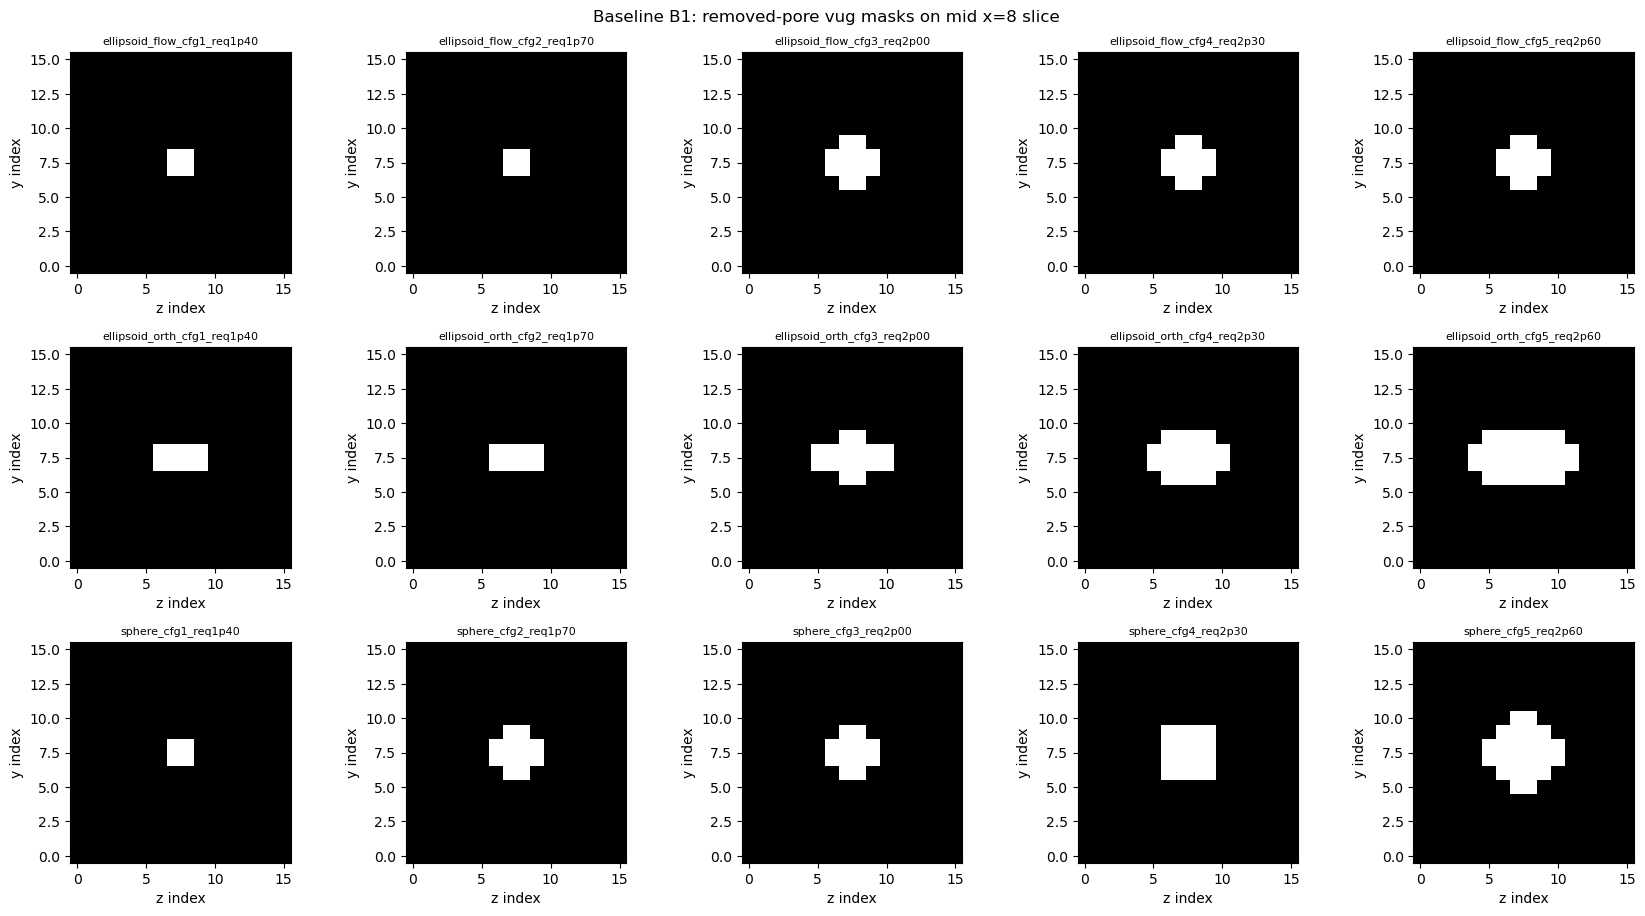

In [9]:
shape3 = tuple(int(v) for v in MESH_SHAPE)
mid_x = shape3[0] // 2
preview_cases = sorted(mask_preview.keys())
ncols = 5
nrows = (len(preview_cases) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.4 * ncols, 3.1 * nrows), squeeze=False
)

for idx, case_name in enumerate(preview_cases):
    ax = axes[idx // ncols, idx % ncols]
    mask3 = np.asarray(mask_preview[case_name], dtype=bool).reshape(shape3)
    ax.imshow(mask3[mid_x], origin="lower", cmap="gray")
    ax.set_title(case_name.replace("B1_", ""), fontsize=8)
    ax.set_xlabel("z index")
    ax.set_ylabel("y index")

for idx in range(len(preview_cases), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

fig.suptitle(f"Baseline B1: removed-pore vug masks on mid x={mid_x} slice")
plt.tight_layout()
plt.show()

## Aggregate response across baselines

Report mean ± std for porosity and normalized permeability for each template.


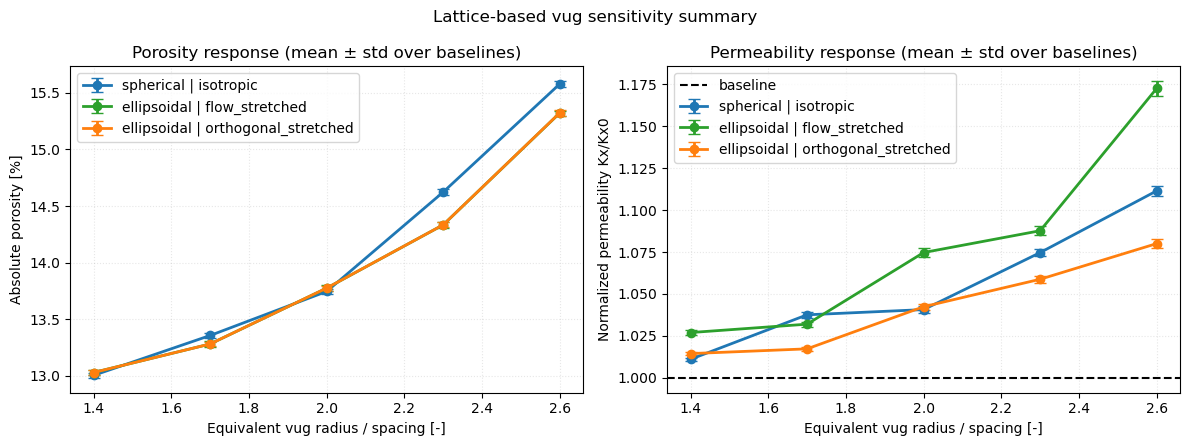

In [10]:
aggregated: dict[tuple[str, str, int], dict[str, object]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    key = (str(row["family"]), str(row["orientation"]), int(row["config_index"]))
    if key not in aggregated:
        aggregated[key] = {
            "equivalent_radius_spacing": float(row["equivalent_radius_spacing"]),
            "k_ratio": [],
            "phi_abs": [],
        }
    aggregated[key]["k_ratio"].append(float(row["K_ratio_to_baseline"]))
    aggregated[key]["phi_abs"].append(float(row["phi_abs"]))

orientation_groups = [
    ("spherical", "isotropic", "tab:blue"),
    ("ellipsoidal", "flow_stretched", "tab:green"),
    ("ellipsoidal", "orthogonal_stretched", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for family, orientation, color in orientation_groups:
    keys = sorted(
        [k for k in aggregated if k[0] == family and k[1] == orientation],
        key=lambda k: k[2],
    )
    if not keys:
        continue
    r_eq = np.array(
        [aggregated[k]["equivalent_radius_spacing"] for k in keys], dtype=float
    )
    k_mean = np.array([np.mean(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    k_std = np.array([np.std(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    phi_mean = 100.0 * np.array(
        [np.mean(aggregated[k]["phi_abs"]) for k in keys], dtype=float
    )
    phi_std = 100.0 * np.array(
        [np.std(aggregated[k]["phi_abs"]) for k in keys], dtype=float
    )

    label = f"{family} | {orientation}"
    axes[0].errorbar(
        r_eq,
        phi_mean,
        yerr=phi_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )
    axes[1].errorbar(
        r_eq,
        k_mean,
        yerr=k_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )

axes[0].set_xlabel("Equivalent vug radius / spacing [-]")
axes[0].set_ylabel("Absolute porosity [%]")
axes[0].set_title("Porosity response (mean ± std over baselines)")
axes[0].grid(alpha=0.3, linestyle=":")
axes[0].legend()

axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_xlabel("Equivalent vug radius / spacing [-]")
axes[1].set_ylabel(f"Normalized permeability K{FLOW_AXIS}/K{FLOW_AXIS}0")
axes[1].set_title("Permeability response (mean ± std over baselines)")
axes[1].grid(alpha=0.3, linestyle=":")
axes[1].legend()

fig.suptitle("Lattice-based vug sensitivity summary")
plt.tight_layout()
plt.show()

## K/K0 frequency distributions parametrized by equivalent radius

For each equivalent radius level, plot frequency histograms of `K/K0` grouped by
vug configuration family/orientation.


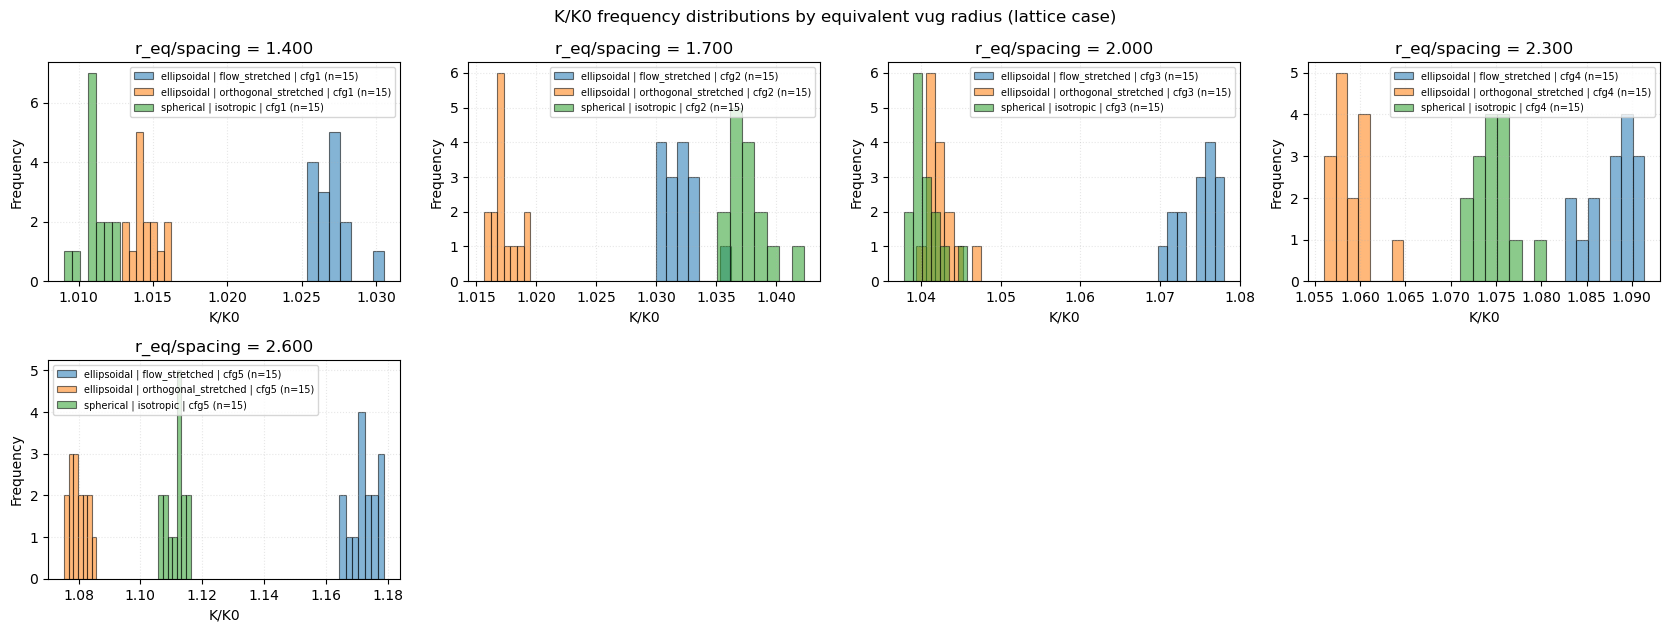

In [11]:
kk0_by_radius_and_config: dict[float, dict[str, list[float]]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    r_key = round(float(row["equivalent_radius_spacing"]), 3)
    cfg_label = (
        f"{row['family']} | {row['orientation']} | cfg{int(row['config_index'])}"
    )
    if r_key not in kk0_by_radius_and_config:
        kk0_by_radius_and_config[r_key] = {}
    if cfg_label not in kk0_by_radius_and_config[r_key]:
        kk0_by_radius_and_config[r_key][cfg_label] = []
    kk0_by_radius_and_config[r_key][cfg_label].append(float(row["K_ratio_to_baseline"]))

radius_keys = sorted(kk0_by_radius_and_config.keys())
ncols_hist = min(4, max(1, len(radius_keys)))
nrows_hist = (len(radius_keys) + ncols_hist - 1) // ncols_hist
fig, axes = plt.subplots(
    nrows_hist,
    ncols_hist,
    figsize=(4.2 * ncols_hist, 3.2 * nrows_hist),
    squeeze=False,
)

for ax, radius_key in zip(axes.flat, radius_keys):
    cfg_map = kk0_by_radius_and_config[radius_key]
    for cfg_label, values in sorted(cfg_map.items()):
        vals = np.asarray(values, dtype=float)
        if vals.size == 0:
            continue
        bins = np.histogram_bin_edges(vals, bins=min(10, max(5, vals.size // 2)))
        if np.unique(bins).size < 2:
            center = float(vals.mean())
            bins = np.array([center - 0.03, center + 0.03], dtype=float)
        ax.hist(
            vals,
            bins=bins,
            alpha=0.55,
            edgecolor="black",
            linewidth=0.8,
            label=f"{cfg_label} (n={vals.size})",
        )
    ax.set_title(f"r_eq/spacing = {radius_key:.3f}")
    ax.set_xlabel("K/K0")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(fontsize=7)

for ax in axes.flat[len(radius_keys) :]:
    ax.axis("off")

fig.suptitle("K/K0 frequency distributions by equivalent vug radius (lattice case)")
plt.tight_layout()
plt.show()

## Interpretation and caveats

Checks to validate in your run:

- vug insertion changes both porosity and connectivity, not porosity alone
- orientation effects can appear at similar equivalent radii
- baseline heterogeneity broadens `K/K0` distributions

Potentially incorrect assumptions:

- replacing an ellipsoidal pore subset by one super-pore is one coarse vug model
- throat sizing at the vug interface is heuristic and influences conductance strongly
- lattice topology is regular and does not reproduce realistic pore-space disorder
